## Cricles Classification

#### Import libs

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split


torch.__version__

'2.10.0'

#### Device Agnostic Code

In [9]:
device = 'cpu'
if torch.mps.is_available(): device = 'mps'
if torch.cuda.is_available(): device = 'cuda'

#### Creating Data

In [71]:
X, y = make_circles(n_samples=10000, random_state=42, noise=0.03)

print(X.shape, y.shape)

(10000, 2) (10000,)


#### Split data to train and test

In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)

#### From python array to torch.Tensor

In [73]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

#### Helper Functions

In [33]:
from helper_functions import *

#### Plot Raw Data

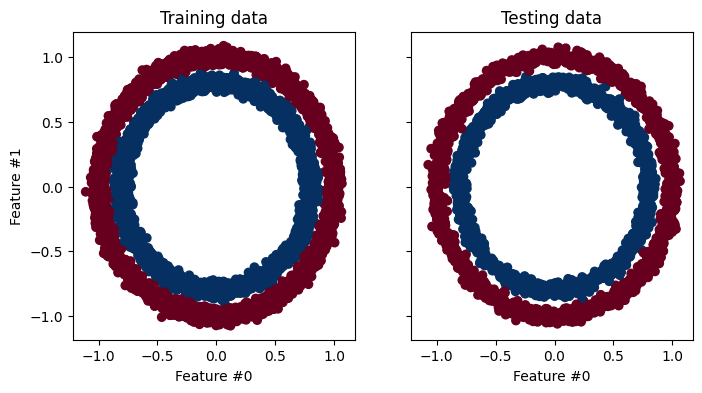

In [75]:
_, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(8, 4))

train_ax.scatter(X_train.cpu()[:, 0], X_train.cpu()[:, 1], c=y_train.cpu(), cmap=plt.cm.RdBu)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training data")

test_ax.scatter(X_test.cpu()[:, 0], X_test.cpu()[:, 1], c=y_test.cpu(), cmap=plt.cm.RdBu)
test_ax.set_xlabel("Feature #0")
_ = test_ax.set_title("Testing data")

#### Model Building

In [76]:
class CircleClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 10)
        self.layer2 = nn.Linear(10, 10)
        self.layer3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

#### Model, Optimizer and Loss function initialization

In [77]:
model0 = CircleClassifier().to(device)
optimizer = torch.optim.Adam(params=model0.parameters(), lr=0.005)
loss_fn = nn.BCEWithLogitsLoss()
if device == "mps":
    torch.mps.manual_seed(42)

In [78]:
epochs = 200 # number of epochs
for epoch in range(epochs):

    model0.train()
    y_train_logits = model0(X_train).squeeze()
    train_loss = loss_fn(y_train_logits, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model0.eval()
        with torch.inference_mode():
            y_test_logits = model0(X_test).squeeze()
            test_loss = loss_fn(y_test_logits, y_test)

            y_test_pred = torch.round(torch.sigmoid(y_test_logits))
            acc = accuracy_fn(y_test, y_test_pred)

        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Acc: {acc:.2f}%")

Epoch: 0 | Train Loss: 0.6974 | Test Loss: 0.6954 | Acc: 47.33%
Epoch: 10 | Train Loss: 0.6912 | Test Loss: 0.6907 | Acc: 53.48%
Epoch: 20 | Train Loss: 0.6868 | Test Loss: 0.6875 | Acc: 53.52%
Epoch: 30 | Train Loss: 0.6809 | Test Loss: 0.6822 | Acc: 56.03%
Epoch: 40 | Train Loss: 0.6708 | Test Loss: 0.6718 | Acc: 56.85%
Epoch: 50 | Train Loss: 0.6536 | Test Loss: 0.6540 | Acc: 60.24%
Epoch: 60 | Train Loss: 0.6259 | Test Loss: 0.6247 | Acc: 73.27%
Epoch: 70 | Train Loss: 0.5843 | Test Loss: 0.5820 | Acc: 90.33%
Epoch: 80 | Train Loss: 0.5309 | Test Loss: 0.5271 | Acc: 95.21%
Epoch: 90 | Train Loss: 0.4676 | Test Loss: 0.4633 | Acc: 95.52%
Epoch: 100 | Train Loss: 0.3976 | Test Loss: 0.3929 | Acc: 96.21%
Epoch: 110 | Train Loss: 0.3263 | Test Loss: 0.3214 | Acc: 97.91%
Epoch: 120 | Train Loss: 0.2591 | Test Loss: 0.2548 | Acc: 99.45%
Epoch: 130 | Train Loss: 0.1996 | Test Loss: 0.1953 | Acc: 99.88%
Epoch: 140 | Train Loss: 0.1501 | Test Loss: 0.1453 | Acc: 99.97%
Epoch: 150 | Train Lo

#### Plot Decision Boundary

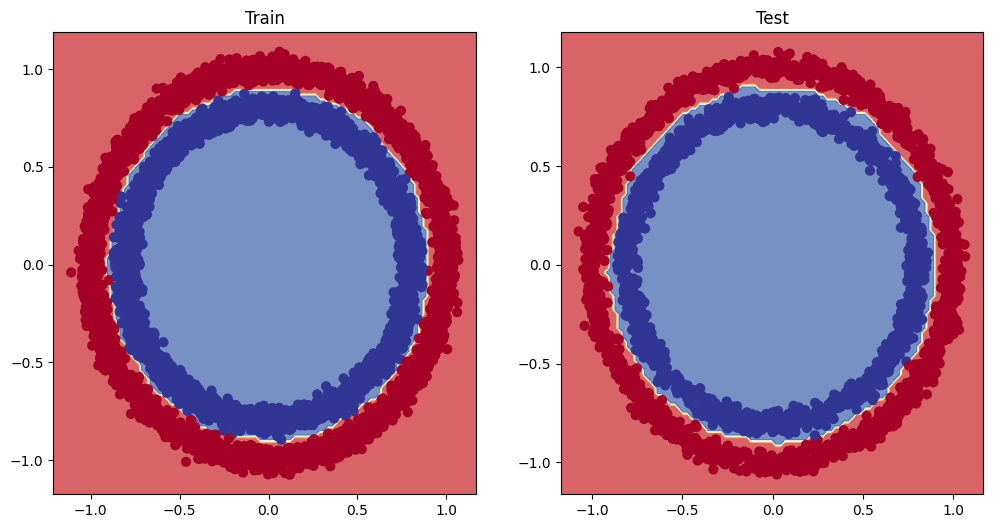

In [79]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model0, X_train, y_train, device)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model0, X_test, y_test, device)

#### Save trained model

In [84]:
torch.save(obj=model0.state_dict(), f="best_model.pth")

#### Reload and Test model

In [89]:
state_dict = torch.load("best_model.pth")
model1 = CircleClassifier().to(device)
model1.load_state_dict(state_dict)

<All keys matched successfully>

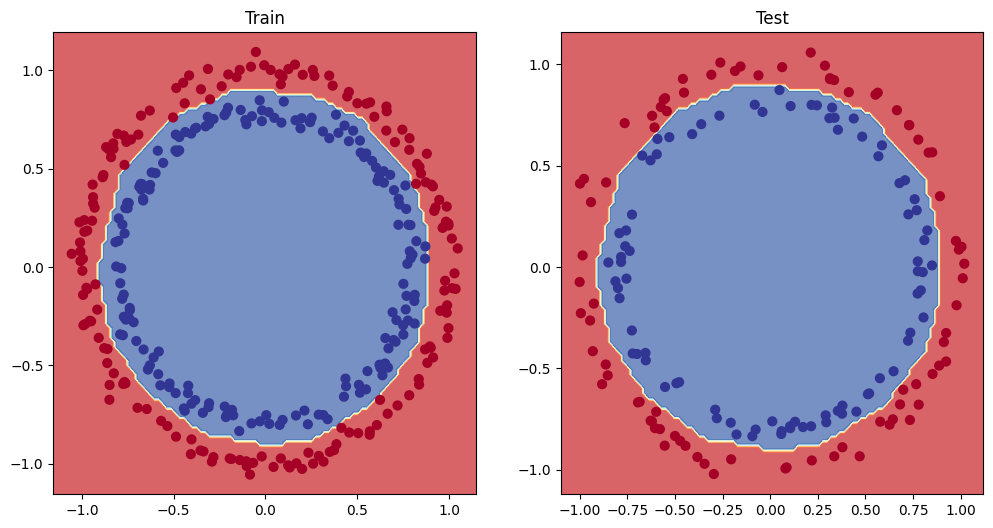

In [93]:
# recreating dataset
X, y = make_circles(n_samples=500, random_state=42, noise=0.03)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)

X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model1, X_train, y_train, device)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model1, X_test, y_test, device)

# MultiClass Classification

In [29]:
from sklearn.datasets import make_blobs
from torchmetrics import Accuracy

In [19]:
X, y = make_blobs(n_samples=1000, n_features=2, centers=None, cluster_std=2.0, center_box=(-10.0, 10.0), shuffle=True, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y)

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

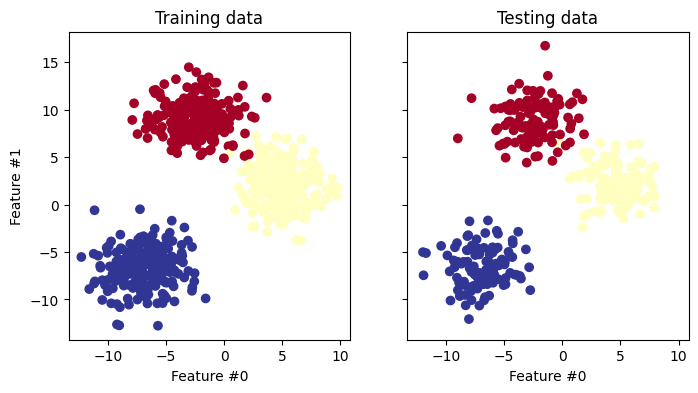

In [21]:
_, (train_ax, test_ax) = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(8, 4))

train_ax.scatter(X_train.cpu()[:, 0], X_train.cpu()[:, 1], c=y_train.cpu(), cmap=plt.cm.RdYlBu)
train_ax.set_ylabel("Feature #1")
train_ax.set_xlabel("Feature #0")
train_ax.set_title("Training data")

test_ax.scatter(X_test.cpu()[:, 0], X_test.cpu()[:, 1], c=y_test.cpu(), cmap=plt.cm.RdYlBu)
test_ax.set_xlabel("Feature #0")
_ = test_ax.set_title("Testing data")

In [22]:
class BlobClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Sequential(
            nn.Linear(2, 10),
            nn.Linear(10, 10),
            nn.Linear(10, 3)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [26]:
model0 = BlobClassifier().to(device)
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.005)
loss_fn = nn.CrossEntropyLoss()
if device == "mps":
    torch.mps.manual_seed(42)

In [31]:
epochs = 200 # number of epochs
for epoch in range(epochs):

    model0.train()
    y_train_logits = model0(X_train).squeeze()
    train_loss = loss_fn(y_train_logits, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        model0.eval()
        with torch.inference_mode():
            y_test_logits = model0(X_test).squeeze()
            test_loss = loss_fn(y_test_logits, y_test)
            accuracy = Accuracy(task="multiclass", num_classes=3).to(device)

            y_test_pred = torch.round(torch.sigmoid(y_test_logits))
            acc = accuracy(y_test_pred, y_test)

        print(f"Epoch: {epoch} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | Acc: {acc:.2f}%")

Epoch: 0 | Train Loss: 0.7048 | Test Loss: 0.6108 | Acc: 0.67%
Epoch: 10 | Train Loss: 0.3059 | Test Loss: 0.3078 | Acc: 0.70%
Epoch: 20 | Train Loss: 0.2129 | Test Loss: 0.2258 | Acc: 0.72%
Epoch: 30 | Train Loss: 0.1663 | Test Loss: 0.1823 | Acc: 0.72%
Epoch: 40 | Train Loss: 0.1377 | Test Loss: 0.1546 | Acc: 0.73%
Epoch: 50 | Train Loss: 0.1183 | Test Loss: 0.1353 | Acc: 0.74%
Epoch: 60 | Train Loss: 0.1042 | Test Loss: 0.1211 | Acc: 0.75%
Epoch: 70 | Train Loss: 0.0935 | Test Loss: 0.1102 | Acc: 0.75%
Epoch: 80 | Train Loss: 0.0851 | Test Loss: 0.1015 | Acc: 0.75%
Epoch: 90 | Train Loss: 0.0784 | Test Loss: 0.0944 | Acc: 0.75%
Epoch: 100 | Train Loss: 0.0728 | Test Loss: 0.0885 | Acc: 0.75%
Epoch: 110 | Train Loss: 0.0681 | Test Loss: 0.0836 | Acc: 0.75%
Epoch: 120 | Train Loss: 0.0642 | Test Loss: 0.0793 | Acc: 0.75%
Epoch: 130 | Train Loss: 0.0607 | Test Loss: 0.0757 | Acc: 0.75%
Epoch: 140 | Train Loss: 0.0577 | Test Loss: 0.0725 | Acc: 0.75%
Epoch: 150 | Train Loss: 0.0551 | Te

In [28]:
!uv pip install torchmetrics

Using Python 3.14.2 environment at: /Users/yusufaxmad/Documents/ai/learning/pytorch-deep-learning/.venv
Resolved 14 packages in 1.35s                                        
Prepared 2 packages in 579ms                                             
Installed 2 packages in 8ms                                 
 + lightning-utilities==0.15.2
 + torchmetrics==1.8.2


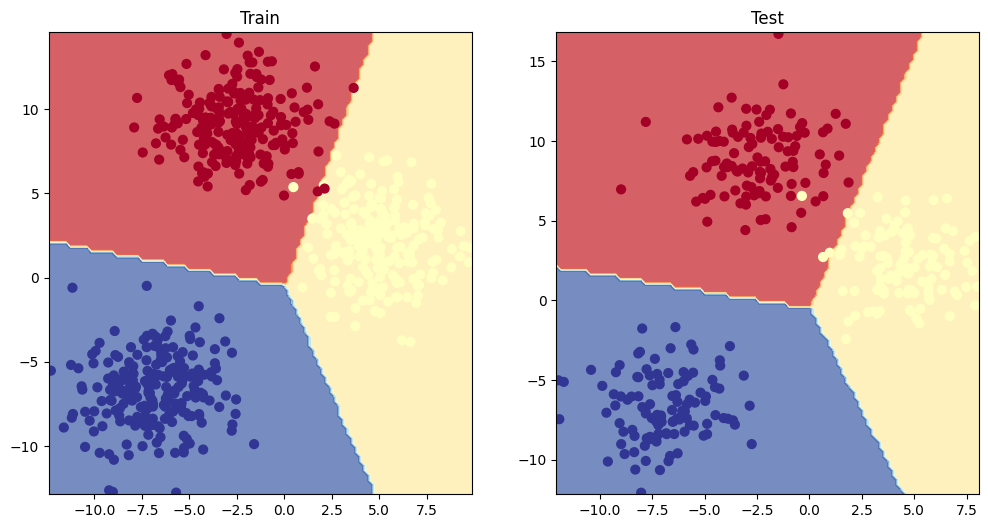

In [34]:
plt.figure(figsize=(12, 6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model0, X_train, y_train, device)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model0, X_test, y_test, device)